12: временные ряды, корректная валидация по времени, лаговые признаки и базовый прогноз с GRU.

In [2]:
import random
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import sklearn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print(f"torch: {torch.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

DATA_PATH       = Path('S12-hw-dataset.csv')
ARTIFACTS_DIR   = Path('artifacts')
FIGURES_DIR     = ARTIFACTS_DIR / 'figures'
RUNS_CSV        = ARTIFACTS_DIR / 'runs.csv'
BEST_GRU_PT     = ARTIFACTS_DIR / 'best_gru.pt'
BEST_GRU_CFG    = ARTIFACTS_DIR / 'best_gru_config.json'

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Directories ready.')

Device: cpu
torch: 2.10.0+cpu
pandas: 2.3.3
numpy: 2.3.5
scikit-learn: 1.8.0
Directories ready.


загрузка данных и первичный анализ

In [3]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('Sanity-check')
print(f'Наблюдений : {len(df):,}')
print(f'Диапазон дат: {df["date"].min()} — {df["date"].max()}')
print(f'Пропуски:\n{df.isnull().sum()}')
print()
df.head()

Sanity-check
Наблюдений : 4,320
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Пропуски:
date      0
target    0
dtype: int64



,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [4]:
print(df['target'].describe())

count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


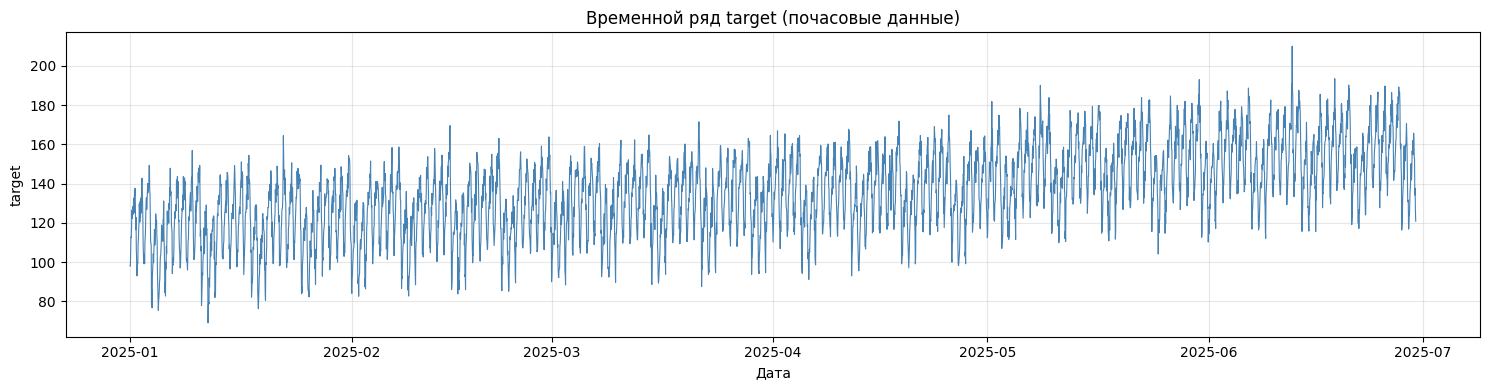

In [5]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df['date'], df['target'], lw=0.8, color='steelblue')
ax.set_title('Временной ряд target (почасовые данные)')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
plt.tight_layout()
plt.show()

На графике исходного ряда визуально прослеживается сезонность (так как данные почасовые, скорее всего присутствует суточный цикл). Также можно заметить локальные тренды (плавное изменение базового уровня) и наличие некоторого шума. Экстремальных выбросов, радикально искажающих масштаб, почти не наблюдается (там пару штук вышло за пределы)

In [6]:
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print('Train : {} — {}  ({} obs)'.format(
    train_df['date'].min().date(), train_df['date'].max().date(), len(train_df)))
print('Val   : {} — {}  ({} obs)'.format(
    val_df['date'].min().date(), val_df['date'].max().date(), len(val_df)))
print('Test  : {} — {}  ({} obs)'.format(
    test_df['date'].min().date(), test_df['date'].max().date(), len(test_df)))

SPLIT_SUMMARY = (
    f'train={train_df["date"].min().date()}/{train_df["date"].max().date()} '
    f'val={val_df["date"].min().date()}/{val_df["date"].max().date()} '
    f'test={test_df["date"].min().date()}/{test_df["date"].max().date()}'
)

Train : 2025-01-01 — 2025-05-06  (3024 obs)
Val   : 2025-05-07 — 2025-06-02  (648 obs)
Test  : 2025-06-03 — 2025-06-29  (648 obs)


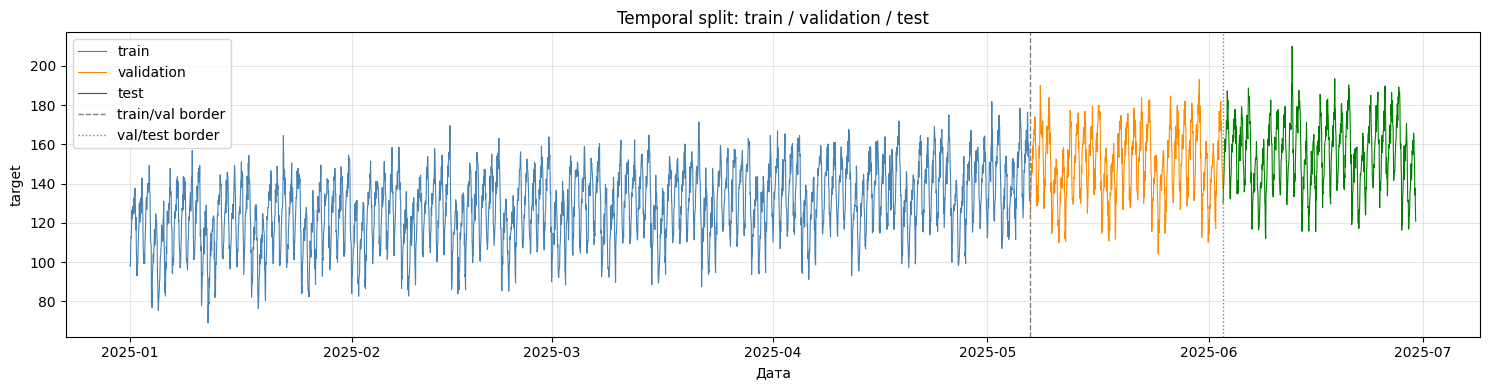

Сохранено: figures/series_split.png


In [7]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df['date'], train_df['target'], label='train',      lw=0.8, color='steelblue')
ax.plot(val_df['date'],   val_df['target'],   label='validation', lw=0.8, color='darkorange')
ax.plot(test_df['date'],  test_df['target'],  label='test',       lw=0.8, color='green')
ax.axvline(train_df['date'].iloc[-1], color='gray', linestyle='--', lw=1, label='train/val border')
ax.axvline(val_df['date'].iloc[-1],   color='gray', linestyle=':',  lw=1, label='val/test border')
ax.set_title('Temporal split: train / validation / test')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'series_split.png', dpi=120)
plt.show()
print('Сохранено: figures/series_split.png')

`random split` некорректен для временных рядов по данной причине:
При случайном разбиении (random split) данные перемешиваются: информация из будущего попадет в обучающую выборку, а данные из "прошлого" — в тестовую. Это приводит к утечке данных. В реальности мы предсказываем будущее, опираясь исключительно на факты из прошлого. Поэтому разбиение должно быть строго хронологическим (temporal split), чтобы корректно симулировать ситуацию прогнозирования будущего.

4. Признаки для baseline-моделей (lag + rolling + calendar)

In [8]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Строит lag-, rolling- и календарные признаки без утечки из будущего."""
    d = df.copy()
    d['lag_1']  = d['target'].shift(1)
    d['lag_7']  = d['target'].shift(7)
    d['lag_14'] = d['target'].shift(14)
    d['lag_24'] = d['target'].shift(24)
    d['rolling_mean_7']  = d['target'].shift(1).rolling(7).mean()
    d['rolling_std_7']   = d['target'].shift(1).rolling(7).std()
    d['rolling_mean_24'] = d['target'].shift(1).rolling(24).mean()
    d['hour']        = d['date'].dt.hour
    d['day_of_week'] = d['date'].dt.dayofweek  # 0=Пн … 6=Вс
    d['day_of_month']= d['date'].dt.day
    d['month']       = d['date'].dt.month
    d['is_weekend']  = (d['day_of_week'] >= 5).astype(int)
    return d

df_feat = build_features(df)

FEATURE_COLS = [
    'lag_1', 'lag_7', 'lag_14', 'lag_24',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24',
    'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend'
]

def get_split(df_feat, split_df):
    idx = split_df.index
    part = df_feat.loc[idx].dropna(subset=FEATURE_COLS)
    X = part[FEATURE_COLS].values
    y = part['target'].values
    return X, y, part

X_train, y_train, train_clean = get_split(df_feat, train_df)
X_val,   y_val,   val_clean   = get_split(df_feat, val_df)
X_test,  y_test,  test_clean  = get_split(df_feat, test_df)

print('Train X:', X_train.shape, ' y:', y_train.shape)
print('Val   X:', X_val.shape,   ' y:', y_val.shape)
print('Test  X:', X_test.shape,  ' y:', y_test.shape)

Train X: (3000, 12)  y: (3000,)
Val   X: (648, 12)  y: (648,)
Test  X: (648, 12)  y: (648,)


In [9]:
# Масштабирование признаков — fit только на train
feat_scaler = StandardScaler()
X_train_sc = feat_scaler.fit_transform(X_train)
X_val_sc   = feat_scaler.transform(X_val)
X_test_sc  = feat_scaler.transform(X_test)
print('Features scaled.')

Features scaled.


In [10]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return 100.0 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    return 100.0 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask])

def eval_metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mp   = mape(y_true, y_pred)
    print(f'[{label}]  MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mp:.2f}%')
    return dict(mae=mae, rmse=rmse, mape=mp)


Эксперименты B1 — B3 (Baselines)

## B1


In [11]:
val_clean_b1 = val_clean.dropna(subset=['lag_1'])
test_clean_b1 = test_clean.dropna(subset=['lag_1'])

b1_val_pred  = val_clean_b1['lag_1'].values
b1_test_pred = test_clean_b1['lag_1'].values

b1_val  = eval_metrics(val_clean_b1['target'].values,  b1_val_pred,  'B1 Val')
b1_test = eval_metrics(test_clean_b1['target'].values, b1_test_pred, 'B1 Test')

[B1 Val]  MAE=6.4448  RMSE=8.2010  MAPE=4.40%
[B1 Test]  MAE=6.3424  RMSE=8.0591  MAPE=4.15%


## B2

In [12]:
val_clean_b2  = val_clean.dropna(subset=['rolling_mean_24'])
test_clean_b2 = test_clean.dropna(subset=['rolling_mean_24'])

b2_val_pred  = val_clean_b2['rolling_mean_24'].values
b2_test_pred = test_clean_b2['rolling_mean_24'].values

b2_val  = eval_metrics(val_clean_b2['target'].values,  b2_val_pred,  'B2 Val')
b2_test = eval_metrics(test_clean_b2['target'].values, b2_test_pred, 'B2 Test')

[B2 Val]  MAE=13.3980  RMSE=16.1699  MAPE=9.20%
[B2 Test]  MAE=13.1405  RMSE=16.1108  MAPE=8.74%


## B3


In [13]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)

b3_val_pred  = ridge.predict(X_val_sc)
b3_test_pred = ridge.predict(X_test_sc)

b3_val  = eval_metrics(y_val,  b3_val_pred,  'B3 Val')
b3_test = eval_metrics(y_test, b3_test_pred, 'B3 Test')

[B3 Val]  MAE=5.9445  RMSE=7.3339  MAPE=3.96%
[B3 Test]  MAE=5.5917  RMSE=6.9932  MAPE=3.59%


Оконное представление для GRU (R1)

In [14]:
WINDOW_SIZE = 24
BATCH_SIZE  = 64
HORIZON     = 1

# Масштабируем target (fit только на train)
target_scaler = StandardScaler()
train_scaled = target_scaler.fit_transform(train_df[['target']]).astype(np.float32)
val_scaled   = target_scaler.transform(val_df[['target']]).astype(np.float32)
test_scaled  = target_scaler.transform(test_df[['target']]).astype(np.float32)

def make_windows(series_2d: np.ndarray, window_size: int):
    """Нарезает ряд на окна (X, y) без утечки."""
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])
        y.append(series_2d[i + window_size, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_tr, y_tr = make_windows(train_scaled, WINDOW_SIZE)
X_vl, y_vl = make_windows(val_scaled,   WINDOW_SIZE)
X_te, y_te = make_windows(test_scaled,  WINDOW_SIZE)

print('X_train:', X_tr.shape, ' y_train:', y_tr.shape)
print('X_val  :', X_vl.shape, ' y_val  :', y_vl.shape)
print('X_test :', X_te.shape, ' y_test :', y_te.shape)

X_train: (3000, 24, 1)  y_train: (3000,)
X_val  : (624, 24, 1)  y_val  : (624,)
X_test : (624, 24, 1)  y_test : (624,)


In [15]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)  # (N, window, 1)
        self.y = torch.tensor(y)  # (N,)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(TimeSeriesDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TimeSeriesDataset(X_vl, y_vl), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TimeSeriesDataset(X_te, y_te), batch_size=BATCH_SIZE, shuffle=False)

In [16]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)        # out: (B, T, H)
        return self.fc(out[:, -1, :]).squeeze(-1)   # last hidden -> scalar


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total += loss.item() * len(xb)
    return total / len(loader.dataset)


@torch.no_grad()
def eval_loader(model, loader, criterion, device):
    model.eval()
    total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        total += criterion(pred, yb).item() * len(xb)
    return total / len(loader.dataset)


def fit_model(model, train_loader, val_loader,
              epochs=30, lr=5e-4, device=device,
              save_path: Path = None):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)
    history = {'train_loss': [], 'val_loss': []}
    best_val = float('inf')
    best_state = None

    for epoch in range(1, epochs + 1):
        tr_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss = eval_loader(model, val_loader,   criterion, device)
        scheduler.step(vl_loss)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        if vl_loss < best_val:
            best_val = vl_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{epochs}  train={tr_loss:.6f}  val={vl_loss:.6f}')

    # Загружаем лучший checkpoint
    model.load_state_dict(best_state)
    if save_path:
        torch.save(best_state, save_path)
        print(f'Best model saved -> {save_path}')
    return history


Обучение

In [17]:
GRU_CONFIG = dict(
    input_size=1, hidden_size=64, num_layers=2, dropout=0.1,
    window_size=WINDOW_SIZE, batch_size=BATCH_SIZE,
    lr=5e-4, epochs=40, seed=SEED,
    scaler='StandardScaler'
)

set_seed(SEED)
gru_model = GRUForecaster(
    input_size=GRU_CONFIG['input_size'],
    hidden_size=GRU_CONFIG['hidden_size'],
    num_layers=GRU_CONFIG['num_layers'],
    dropout=GRU_CONFIG['dropout']
).to(device)

print('GRU params:', sum(p.numel() for p in gru_model.parameters()))

gru_history = fit_model(
    gru_model, train_loader, val_loader,
    epochs=GRU_CONFIG['epochs'],
    lr=GRU_CONFIG['lr'],
    device=device,
    save_path=BEST_GRU_PT
)
GRU_CONFIG['epochs_trained'] = GRU_CONFIG['epochs']

GRU params: 37889


Epoch   1/40  train=0.716624  val=0.686312
Epoch   5/40  train=0.155837  val=0.213104
Epoch  10/40  train=0.147197  val=0.218803
Epoch  15/40  train=0.124089  val=0.203893
Epoch  20/40  train=0.104556  val=0.161520
Epoch  25/40  train=0.101504  val=0.166649
Epoch  30/40  train=0.101084  val=0.164268
Epoch  35/40  train=0.101216  val=0.170671
Epoch  40/40  train=0.099224  val=0.166978
Best model saved -> artifacts\best_gru.pt


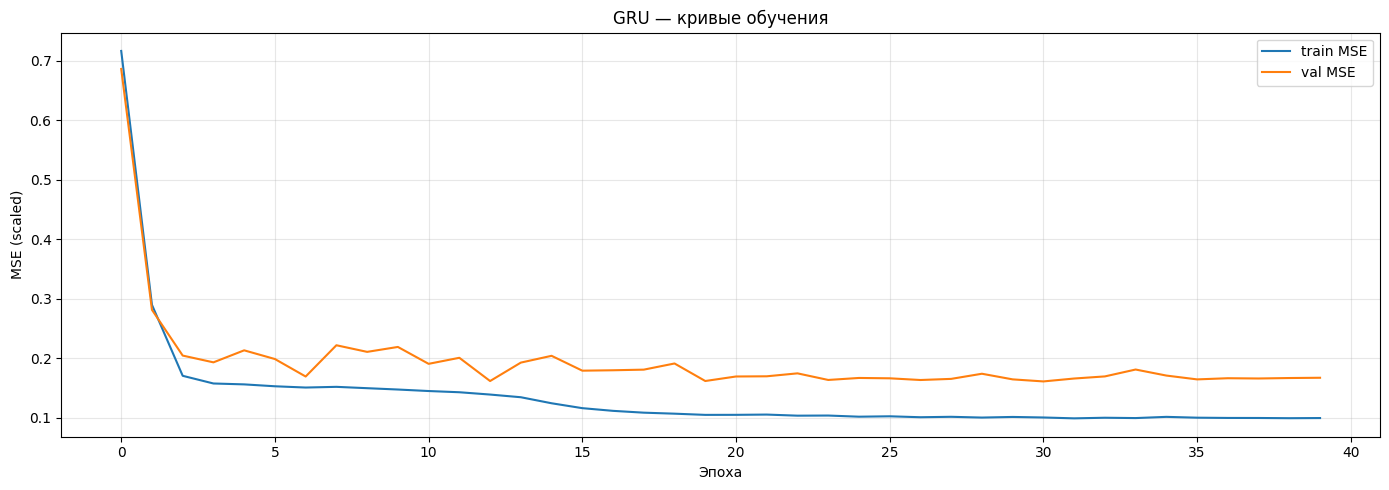

Сохранено: figures/gru_learning_curves.png


In [18]:
# Кривые обучения
fig, ax = plt.subplots()
ax.plot(gru_history['train_loss'], label='train MSE')
ax.plot(gru_history['val_loss'],   label='val MSE')
ax.set_title('GRU — кривые обучения')
ax.set_xlabel('Эпоха')
ax.set_ylabel('MSE (scaled)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gru_learning_curves.png', dpi=120)
plt.show()
print('Сохранено: figures/gru_learning_curves.png')

In [19]:
@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    preds = []
    for xb, _ in loader:
        preds.append(model(xb.to(device)).cpu().numpy())
    return np.concatenate(preds)

# Метрики на validation
gru_val_pred_sc  = predict_loader(gru_model, val_loader,  device)
gru_test_pred_sc = predict_loader(gru_model, test_loader, device)

# Обратное масштабирование
gru_val_pred  = target_scaler.inverse_transform(gru_val_pred_sc.reshape(-1,1)).ravel()
gru_test_pred = target_scaler.inverse_transform(gru_test_pred_sc.reshape(-1,1)).ravel()

# Соответствующие истинные значения (без первых WINDOW_SIZE точек)
y_val_orig  = val_df['target'].values[WINDOW_SIZE:]
y_test_orig = test_df['target'].values[WINDOW_SIZE:]

r1_val  = eval_metrics(y_val_orig,  gru_val_pred,  'R1 Val')
r1_test = eval_metrics(y_test_orig, gru_test_pred, 'R1 Test')

[R1 Val]  MAE=5.7928  RMSE=7.4114  MAPE=3.89%
[R1 Test]  MAE=6.8728  RMSE=8.6702  MAPE=4.41%


In [20]:
results = {
    'B1 (naive-last)':    b1_val['mae'],
    'B2 (moving-avg)':    b2_val['mae'],
    'B3 (ridge)':         b3_val['mae'],
    'R1 (gru-forecast)':  r1_val['mae'],
}

best_name = min(results, key=results.get)
print('=== Validation MAE ===')
for k, v in sorted(results.items(), key=lambda x: x[1]):
    mark = ' <-- BEST' if k == best_name else ''
    print(f'  {k:<25} {v:.4f}{mark}')
print()
print('Лучшая модель по validation MAE:', best_name)

=== Validation MAE ===
  R1 (gru-forecast)         5.7928 <-- BEST
  B3 (ridge)                5.9445
  B1 (naive-last)           6.4448
  B2 (moving-avg)           13.3980

Лучшая модель по validation MAE: R1 (gru-forecast)


In [21]:
print('=== Финальная оценка на TEST (лучшая модель) ===')
print(f'Выбрана: {best_name}')
final_test = eval_metrics(y_test_orig, gru_test_pred, f'{best_name} Test')

=== Финальная оценка на TEST (лучшая модель) ===
Выбрана: R1 (gru-forecast)
[R1 (gru-forecast) Test]  MAE=6.8728  RMSE=8.6702  MAPE=4.41%


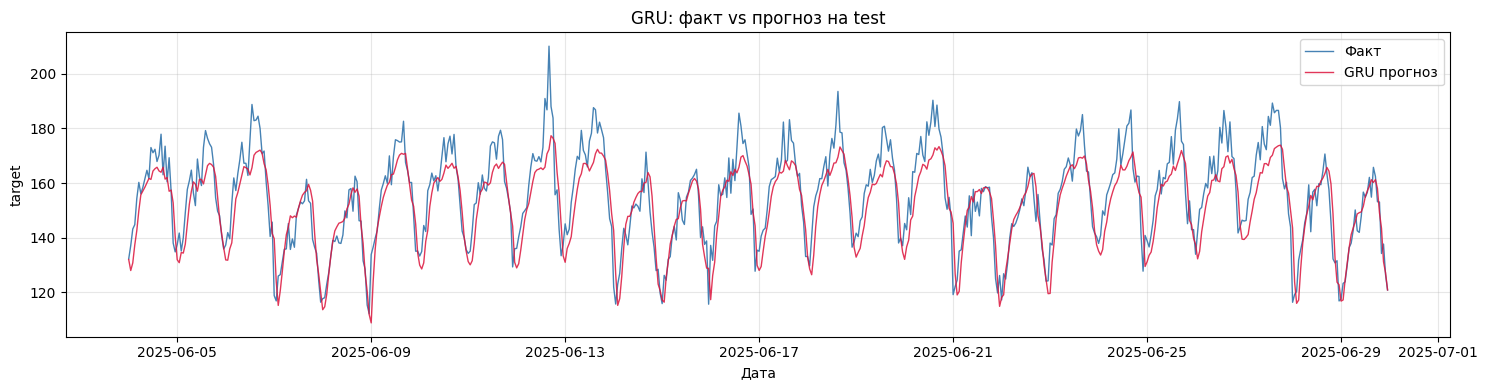

Сохранено: figures/best_forecast_test.png


In [22]:
test_dates = test_df['date'].values[WINDOW_SIZE:]

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(test_dates, y_test_orig,  label='Факт',   lw=1.0, color='steelblue')
ax.plot(test_dates, gru_test_pred, label='GRU прогноз', lw=1.0, color='crimson', alpha=0.85)
ax.set_title('GRU: факт vs прогноз на test')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'best_forecast_test.png', dpi=120)
plt.show()
print('Сохранено: figures/best_forecast_test.png')

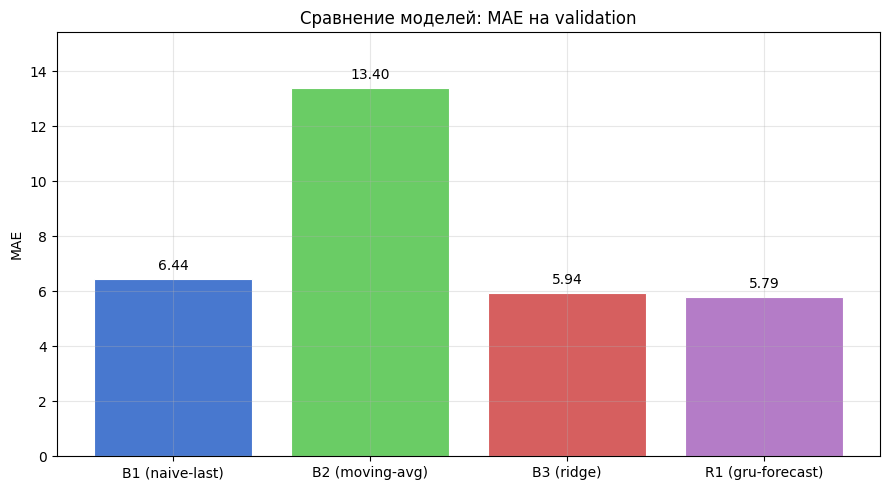

Сохранено: figures/baselines_compare.png


In [23]:
# Сравнение baseline по val MAE
labels = list(results.keys())
maes   = list(results.values())
colors = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, maes, color=colors, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.2, f'{v:.2f}',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Сравнение моделей: MAE на validation')
ax.set_ylabel('MAE')
ax.set_ylim(0, max(maes) * 1.15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baselines_compare.png', dpi=120)
plt.show()
print('Сохранено: figures/baselines_compare.png')

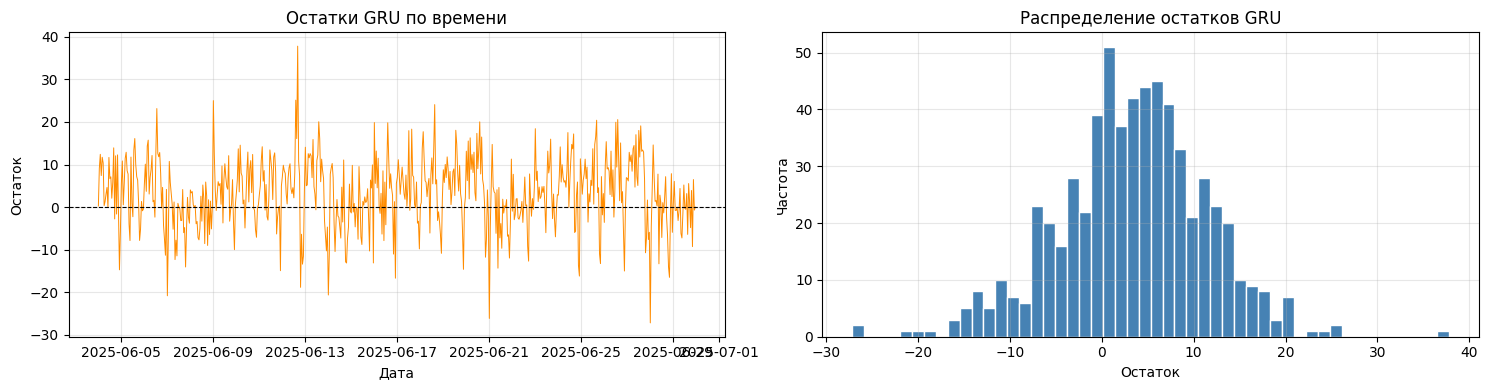

Сохранено: figures/residuals_best.png


In [24]:
# Остатки лучшей модели
residuals = y_test_orig - gru_test_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(test_dates, residuals, lw=0.7, color='darkorange')
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_title('Остатки GRU по времени')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Остаток')

axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Распределение остатков GRU')
axes[1].set_xlabel('Остаток')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'residuals_best.png', dpi=120)
plt.show()
print('Сохранено: figures/residuals_best.png')

In [25]:
NA = ''
runs = [
    dict(
        experiment_id='B1', task='forecasting', dataset='S12-hw-dataset.csv',
        seed=SEED, split_summary=SPLIT_SUMMARY,
        window_size=NA, horizon=1,
        model_summary='naive-last (lag_1)',
        features_summary='lag_1',
        scaler=NA, optimizer=NA, lr=NA, epochs_trained=NA,
        best_val_mae=round(b1_val['mae'],4),
        best_val_rmse=round(b1_val['rmse'],4),
        best_val_mape=round(b1_val['mape'],4),
        test_mae=NA, test_rmse=NA, test_mape=NA,
        notes='Baseline: прогноз = последнее значение'
    ),
    dict(
        experiment_id='B2', task='forecasting', dataset='S12-hw-dataset.csv',
        seed=SEED, split_summary=SPLIT_SUMMARY,
        window_size=24, horizon=1,
        model_summary='moving-average(24h)',
        features_summary='rolling_mean_24',
        scaler=NA, optimizer=NA, lr=NA, epochs_trained=NA,
        best_val_mae=round(b2_val['mae'],4),
        best_val_rmse=round(b2_val['rmse'],4),
        best_val_mape=round(b2_val['mape'],4),
        test_mae=NA, test_rmse=NA, test_mape=NA,
        notes='Baseline: скользящее среднее за 24 часа'
    ),
    dict(
        experiment_id='B3', task='forecasting', dataset='S12-hw-dataset.csv',
        seed=SEED, split_summary=SPLIT_SUMMARY,
        window_size=NA, horizon=1,
        model_summary='Ridge(alpha=1.0)',
        features_summary='lag_1,lag_7,lag_14,lag_24,rolling_mean_7,rolling_std_7,rolling_mean_24,hour,dow,dom,month,is_weekend',
        scaler='StandardScaler', optimizer=NA, lr=NA, epochs_trained=NA,
        best_val_mae=round(b3_val['mae'],4),
        best_val_rmse=round(b3_val['rmse'],4),
        best_val_mape=round(b3_val['mape'],4),
        test_mae=NA, test_rmse=NA, test_mape=NA,
        notes='Ridge на lag/rolling/calendar признаках'
    ),
    dict(
        experiment_id='R1', task='forecasting', dataset='S12-hw-dataset.csv',
        seed=SEED, split_summary=SPLIT_SUMMARY,
        window_size=WINDOW_SIZE, horizon=HORIZON,
        model_summary=f'GRU(hidden={GRU_CONFIG["hidden_size"]},layers={GRU_CONFIG["num_layers"]},dropout={GRU_CONFIG["dropout"]})',
        features_summary='scaled target windows',
        scaler='StandardScaler',
        optimizer='Adam',
        lr=GRU_CONFIG['lr'],
        epochs_trained=GRU_CONFIG['epochs_trained'],
        best_val_mae=round(r1_val['mae'],4),
        best_val_rmse=round(r1_val['rmse'],4),
        best_val_mape=round(r1_val['mape'],4),
        test_mae=round(r1_test['mae'],4),
        test_rmse=round(r1_test['rmse'],4),
        test_mape=round(r1_test['mape'],4),
        notes='GRU window=24h; best по val_mae; ReduceLROnPlateau'
    ),
]

runs_df = pd.DataFrame(runs)
runs_df.to_csv(RUNS_CSV, index=False)
print('Сохранено: artifacts/runs.csv')
runs_df

Сохранено: artifacts/runs.csv


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,train=2025-01-01/2025-05-06 val=2025-05-07/202...,,1,naive-last (lag_1),lag_1,,,,,6.4448,8.2010,4.3979,,,,Baseline: прогноз = последнее значение
1,B2,forecasting,S12-hw-dataset.csv,42,train=2025-01-01/2025-05-06 val=2025-05-07/202...,24,1,moving-average(24h),rolling_mean_24,,,,,13.3980,16.1699,9.1988,,,,Baseline: скользящее среднее за 24 часа
2,B3,forecasting,S12-hw-dataset.csv,42,train=2025-01-01/2025-05-06 val=2025-05-07/202...,,1,Ridge(alpha=1.0),"lag_1,lag_7,lag_14,lag_24,rolling_mean_7,rolli...",StandardScaler,,,,5.9445,7.3339,3.9562,,,,Ridge на lag/rolling/calendar признаках
3,R1,forecasting,S12-hw-dataset.csv,42,train=2025-01-01/2025-05-06 val=2025-05-07/202...,24,1,"GRU(hidden=64,layers=2,dropout=0.1)",scaled target windows,StandardScaler,Adam,0.0005,40,5.7928,7.4114,3.8901,6.8728,8.6702,4.4084,GRU window=24h; best по val_mae; ReduceLROnPla...


In [26]:
with open(BEST_GRU_CFG, 'w') as f:
    json.dump(GRU_CONFIG, f, indent=2)
print('Сохранено: artifacts/best_gru_config.json')
print(json.dumps(GRU_CONFIG, indent=2))

Сохранено: artifacts/best_gru_config.json
{
  "input_size": 1,
  "hidden_size": 64,
  "num_layers": 2,
  "dropout": 0.1,
  "window_size": 24,
  "batch_size": 64,
  "lr": 0.0005,
  "epochs": 40,
  "seed": 42,
  "scaler": "StandardScaler",
  "epochs_trained": 40
}
